In [64]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from scipy.special import expit  # sigmoid
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

In [65]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and target
y_raw = df['Attrition'].values
X = df.drop(columns=['Attrition']).values
y = (y_raw == y_raw.max()).astype(int)
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Original class distribution (real data):")
print(f"  No Attrition (0): {np.sum(y == 0)}")
print(f"  Attrition    (1): {np.sum(y == 1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Test class distribution (real, untouched):")
print(f"  No Attrition (0): {np.sum(y_test == 0)}")
print(f"  Attrition    (1): {np.sum(y_test == 1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train.shape[0]} samples")
print(f"  No Attrition (0): {np.sum(y_train == 0)}")
print(f"  Attrition    (1): {np.sum(y_train_resampled == 1)}")

Dataset shape: (1470, 37)

Features shape: (1470, 36)
Original class distribution (real data):
  No Attrition (0): 1232
  Attrition    (1): 238

Train: 1176 samples | Test: 294 samples
Test class distribution (real, untouched):
  No Attrition (0): 246
  Attrition    (1): 48

After SMOTE — Train: 1176 samples
  No Attrition (0): 986
  Attrition    (1): 986


In [66]:
class MySVM:
    def __init__(self, C=1, gamma='scale', iterations=1000, lr=0.001, random_state=42):
        self.C = C
        self.gamma = gamma
        self.iterations = iterations
        self.lr = lr
        np.random.seed(random_state)

    def _rbf_kernel(self, X, Z):
        if self.gamma == 'scale':
            self._gamma = 1 / (X.shape[1] * X.var())
        else:
            self._gamma = self.gamma
        
        diff = X[:, np.newaxis] - Z[np.newaxis, :]
        return np.exp(-self._gamma * np.sum(diff**2, axis=2))
    
    def fit(self, X, y):
        y = np.where(y <= 0, -1, 1)
        
        self.X = X
        self.y = y
        n = X.shape[0]
        
        self.alpha = np.random.rand(n)
        self.alpha = np.clip(self.alpha, 0, self.C)
        
        K = self._rbf_kernel(X, X)
        kernel_mat = np.outer(y, y) * K
        
        for _ in range(self.iterations):
            gradient = np.ones(n) - kernel_mat.dot(self.alpha)
            self.alpha += self.lr * gradient
            self.alpha = np.clip(self.alpha, 0, self.C)
        
        # support vectors
        sv = (self.alpha > 1e-5)
        
        # bias
        self.b = np.mean(
            y[sv] - (self.alpha * y).dot(K[:, sv])
        )
        
        # --- Platt scaling simplified ---
        decision = self.decision_function(X)
        self.A = 1
        self.B = -np.mean(decision)

    def decision_function(self, X):
        K = self._rbf_kernel(self.X, X)
        return (self.alpha * self.y).dot(K) + self.b
    
    def predict_proba(self, X):
        decision = self.decision_function(X)
        probs = expit(decision)   # sigmoid
        return np.vstack([1 - probs, probs]).T
    
    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)[:, 1]
        return (probs > threshold).astype(int)

In [67]:
svm_model = MySVM(
    C=1,
    gamma='scale',
    iterations=10000,
    lr=0.001,
    random_state=42
)

svm_model.fit(X_train_resampled, y_train_resampled)

probs = svm_model.predict_proba(X_test)[:, 1]
y_pred = (probs > 0.4).astype(int)

In [68]:
print("ROC-AUC:", roc_auc_score(y_test, probs))
  
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("specificity:", specificity := confusion_matrix(y_test, y_pred)[0, 0] / np.sum(confusion_matrix(y_test, y_pred)[0]))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# import pandas as pd
# import matplotlib.pyplot as plt

# # สร้าง DataFrame สำหรับวิเคราะห์
# risk_df = pd.DataFrame({
#     "probability": probs
# })

# สร้าง risk category
# def categorize_risk(p):
#     if p < 0.3:
#         return "Low Risk"
#     elif p < 0.6:
#         return "Medium Risk"
#     else:
#         return "High Risk"

# risk_df["Risk Level"] = risk_df["probability"].apply(categorize_risk)

# # นับจำนวนแต่ละกลุ่ม
# risk_counts = risk_df["Risk Level"].value_counts()

# print(risk_counts)

# order = ["Low Risk", "Medium Risk", "High Risk"]
# risk_counts = risk_df["Risk Level"].value_counts().reindex(order)

# plt.figure()
# risk_counts.plot(kind='bar')
# plt.title("Employee Attrition Risk Level")
# plt.xlabel("Risk Level")
# plt.ylabel("Number of Employees")
# plt.show()
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.8105521680216802

Accuracy: 0.7653061224489796
specificity: 0.7682926829268293

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       246
           1       0.39      0.75      0.51        48

    accuracy                           0.77       294
   macro avg       0.66      0.76      0.68       294
weighted avg       0.85      0.77      0.79       294


Confusion Matrix:
[[189  57]
 [ 12  36]]


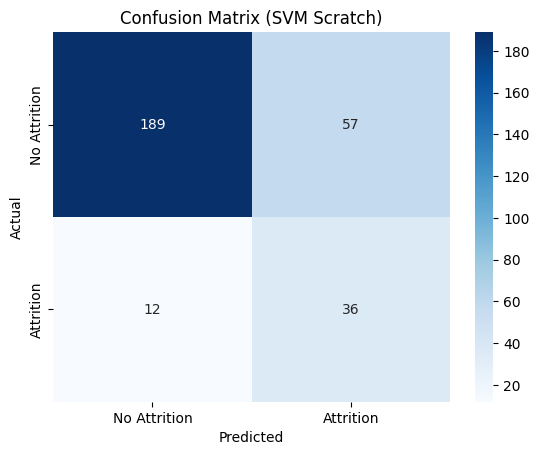

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Confusion Matrix (SVM Scratch)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC: 0.8105521680216802


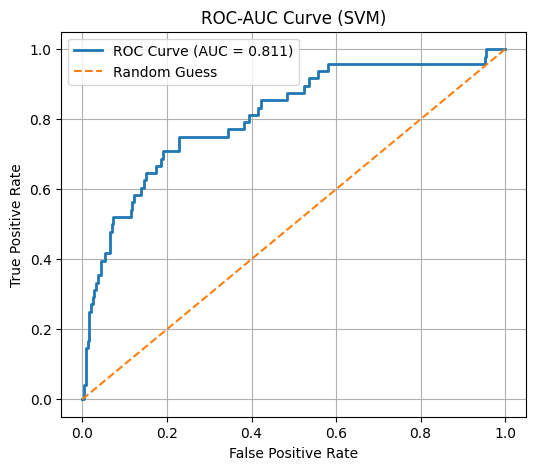

In [70]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# -------------------------
# Predict probability
# -------------------------
probs = svm_model.predict_proba(X_test)[:,1]

# กำหนด threshold
y_pred = (probs > 0.35).astype(int)

# -------------------------
# ROC-AUC Score
# -------------------------
roc_auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", roc_auc)

# -------------------------
# ROC Curve
# -------------------------
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0,1],[0,1],'--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (SVM)")
plt.legend()
plt.grid(True)

plt.show()

In [71]:
# from sklearn.svm import SVC

# svm_model = SVC(
#     kernel='rbf',          # ใช้ RBF kernel (เหมาะกับ HR data)
#     C=1.0,                 # Regularization
#     gamma='scale',         # Default สำหรับ RBF
#     class_weight='balanced',  # แก้ class imbalance
#     random_state=42
# )

# # -------------------------
# # 3) Train Model
# # -------------------------
# svm_model.fit(X_train_resampled, y_train_resampled)

# # -------------------------
# # 4) Predict
# # -------------------------
# y_pred = svm_model.predict(X_test)
# y_pred = (probs > 0.4).astype(int)

# # -------------------------
# # 5) Evaluate
# # -------------------------
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, y_pred))
# print("Specificity:", confusion_matrix(y_test, y_pred)[0,0] / np.sum(confusion_matrix(y_test, y_pred)[0]))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))


Accuracy for library SVM : 0.8299319727891157
ROC-AUC for library SVM : 0.7834518970189703
Specificity for library SVM : 0.9065040650406504
Classification report for library SVM :
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       246
           1       0.48      0.44      0.46        48

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.68       294
weighted avg       0.82      0.83      0.83       294



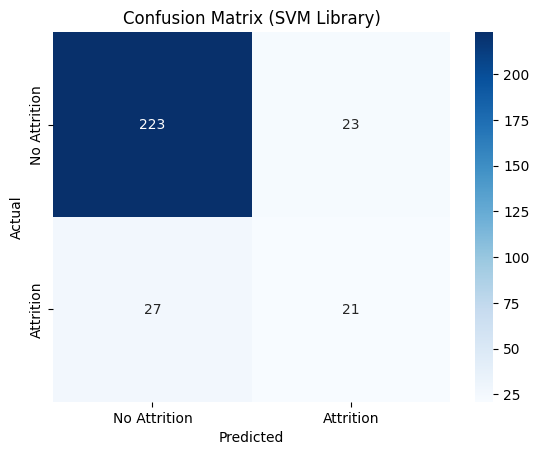

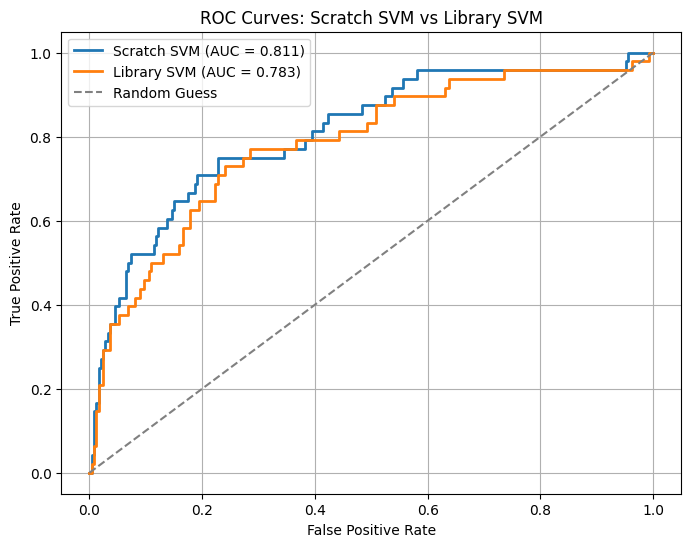

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

# Refit library SVM with probability=True to get predict_proba
svm_lib = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42, probability=True)
svm_lib.fit(X_train_resampled, y_train_resampled)

# Get probabilities for library model
probs_lib = svm_lib.predict_proba(X_test)[:, 1]

print("Accuracy for library SVM :", accuracy_score(y_test, (probs_lib > 0.4).astype(int)))
print("ROC-AUC for library SVM :", roc_auc_score(y_test, probs_lib))
print("Specificity for library SVM :", confusion_matrix(y_test, (probs_lib > 0.4).astype(int))[0, 0] / np.sum(confusion_matrix(y_test, (probs_lib > 0.4).astype(int))[0]))

print("Classification report for library SVM :")
print(classification_report(y_test, (probs_lib > 0.4).astype(int)))
plt.figure()
sns.heatmap(
    confusion_matrix(y_test, (probs_lib > 0.4).astype(int)),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Confusion Matrix (SVM Library)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Compute ROC for library model
fpr_lib, tpr_lib, _ = roc_curve(y_test, probs_lib)
roc_auc_lib = roc_auc_score(y_test, probs_lib)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(my_fpr, my_tpr, label=f'Scratch SVM (AUC = {my_auc:.3f})', linewidth=2)
plt.plot(fpr_lib, tpr_lib, label=f'Library SVM (AUC = {roc_auc_lib:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], '--', label='Random Guess', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Scratch SVM vs Library SVM')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
# use the library svm probabilities with the same cutoff we used earlier
y_pred_lib = (probs_lib > 0.4).astype(int)

print("Classification report for library SVM (threshold=0.4):")
print(classification_report(y_test, y_pred_lib))

Classification report for library SVM (threshold=0.4):
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       246
           1       0.48      0.44      0.46        48

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.68       294
weighted avg       0.82      0.83      0.83       294

